# Деревья решений и композиции

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from pprint import pprint

В этой лабораторной вам предстоит поработать с двумя задачами сразу: классификацией и регрессией. Задача классификации в машинном обучении - это один из основных типов задач, где модель обучается предсказывать категориальную метку или класс для заданного входного наблюдения на основе обучающего набора данных, содержащего пары "входные данные - целевая метка".

Можно выделить несколько видов классификации:

* Binary - целевой признак имеет метку 0/1;
* Multiclass - целевой признак имеет метку из ограниченного множества (0, 1, 2, 3...);
* Multilabel - целевой признак может иметь несколько меток одновременно.

Классификацию можно решать как задачу регрессии (задача предсказания значения из непрерывного множества), затем выбирая порог - всем значениям меньше порога будет присвоена метка 0, всем значениям выше - метка 1.

# Деревья решений

Решающие деревья - алгоритм машинного обучения, с помощью которого можно решать задачи классификации и регрессии. Основная идея алгортитма - это поиск условий принятия решений по тренировочным данным.

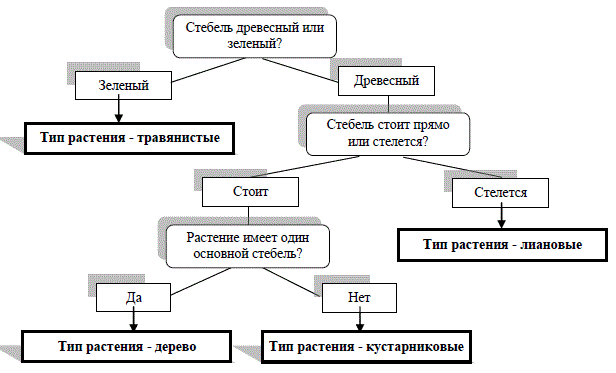

По сути, мы рекурсивно разбиваем наши обучающие данные по значениям определенного столбца, чтобы по итогу в каждом листе оказались наиболее однородные значения целевой переменной.

## Построение дерева

Опишем жадный алгоритм построения бинарного дерева решений:
1. Начинаем со всей обучающей выборки $X$, которую помещаем в корень $R_1$.
2. Задаём функционал качества $Q(X, j, t)$ и критерий остановки.
3. Запускаем построение из корня: $SplitNode(1, R_1)$

Функция $SplitNode(m, R_m)$
1. Если выполнен критерий остановки, то выход.
2. Находим наилучший с точки зрения $Q$ предикат: $j, t$: $[x_j<t]$
3. Помещаем предикат в вершину и получаем с его помощью разбиение $X$ на две части: $R_{left} = \lbrace x|x_j<t \rbrace$ и $R_{right} = \lbrace x|x_j \geqslant t \rbrace$
4. Поместим $R_{left}$ и $R_{right}$ соответсвенно в левое и правое поддерево.
5. Рекурсивно повторяем $SplitNode(left, R_{left})$ и $SplitNode(right, R_{right})$.

В конце поставим в соответствие каждому листу ответ. Для задачи классификации - это самый частый среди объектов класс или вектор с долями классов (можно интерпретировать как вероятности):
$$ c_v = \arg \max_{k\in Y} \sum_{(x_i,y_i) \in R_v} [y_i=k]  $$


Небольшое дополнение, чтобы стало понятнее: $Q$ - это функционал, который определяет то, что мы называем "наилучшим разбиением" для данных на каждом шаге. То есть мы выбираем один столбец, потом для него выбираем число $t$ такое, что часть значений столбца меньше $t$, а оставшаяся часть - больше или равна (дерево работает только с числовыми значениями или с категориальными, если они переведены в числовой формат), и смотрим, что случилось с целевой переменной при таком разбиении. Если допустить, что целевая переменная бинарная (0/1) и до разбиения нолики и единички лежали кучей, то после разбиения мы в идеале хотим получить две кучки, где в одной только нули, а в другой только единицы.

## Функционал качества для деревьев решений


Для классификации чаще всего предлагают следующие два:

- энтропия Шеннона: $-\sum_k{p_{ik}log_2(p_{ik})}$

- индекс Джини: $\sum_{j\neq k}p_{ij}p_{ik} = 1 - \sum_k p_{ik}^2$

где:

* $i$ - ID узлов дерева;

* $k, j$ - идентификаторы классов, представленных в датасете;

* $p_{ik} = \frac{N_{ik}}{N_i}$,

* $p_{ik}$ - вероятность принадлежности класса $k$ узлу $i$,

* $N_{ik}$ - число объектов класса $k$ в узле $i$,

* $N_{i}$ - общее число объектов в узле $i$.



Оба функционала позволяют определить степень хаоса в системе. Интуитивно:
* 0101101010101 - высокая степень хаоса
* 0000010010000 - средняя степень хаоса
* 0000000000000 - низкая степень хаоса

И с помощью дерева для целевой переменной мы хотим добиться чего-то вроде:
0001100011111 -> 00011000 + 11111 -> 000 + 11000 + 11111 -> 000 + 11 + 000 + 11111

Для регрессии в качестве функциона качества можно использовать, например, MSE: $\frac{1}{N_i} \sum_{j=1}^{N_i} (y_j - \bar{y}_i)^2$

где:
* $i$ — ID узла дерева;
* $N_i$ — число объектов в узле $i$;
* $y_j$ — значение целевой переменной для объекта $j$;
* $\bar{y}_i$ — среднее значение ответов в узле, которое вычисляется как:
$$\bar{y}_i = \frac{1}{N_i} \sum_{j=1}^{N_i} y_j$$

Если в классификации индекс Джини или энтропия показыват степень хаоса в распределении меток, то в регрессии MSE показывает дисперсию ответов. Чем ниже значение, тем более похожи числа в узле друг на друга. Другими словами, в задаче классификации мы измеряем чистоту классов, а в регрессии – однородность числовых значений. Поэтому при поиске лучшего разбиения признаки и пороги подбираются так, чтобы минимизировать сумму MSE в левом и правом листьях.

Реализуйте функционалы.

In [ ]:
def entropy(y):  # y - массив значений целевой переменной
    y = np.array(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    # убираем нулевые вероятности, чтобы избежать log(0)
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


def gini_index(y):
    y = np.array(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return float(1 - np.sum(probs ** 2))


def mse(y):
    # импьюрити-версия: дисперсия значений в узле
    y = np.array(y, dtype=float)
    if len(y) == 0:
        return 0.0
    return float(np.mean((y - np.mean(y)) ** 2))


In [ ]:
# Tests

assert np.isclose(entropy([0, 1, 0, 1, 0, 1]), 1.0)
assert np.isclose(entropy([0, 0, 0, 0, 0, 1]), 0.65, rtol=1e5)
assert np.isclose(entropy([0, 1, 2, 0, 1, 2, 0, 1, 2]), 1.58, rtol=1e5)

assert np.isclose(gini_index([0, 1, 0, 1, 0, 1]), 0.5)
assert np.isclose(gini_index([0, 0, 0, 0, 0, 1]), 0.27, rtol=1e5)
assert np.isclose(gini_index([0, 1, 2, 0, 1, 2, 0, 1, 2]), 0.66, rtol=1e5)

assert np.isclose(mse([5, 5, 5, 5]), 0.0)
assert np.isclose(mse([1, 2, 3]), 0.66, atol=1e5)
assert np.isclose(mse([0, 10, 20]), 66.66, atol=1e5)

assert entropy([0, 0, 0, 0, 0, 0]) == gini_index([0, 0, 0, 0, 0, 0]) == mse([0, 0, 0, 0, 0, 0]) == 0.0

print("All tests passed successfully!")

All tests passed successfully!


Энтропия – по сути степень хаоса (или неопределенности) в системе. Уменьшение энтропии называют приростом информации (information gain, IG).

Обочначим $R_v$ - объекты, которые нужно разделить в помощью предиката в вершине $v$. Запишем формулу для расчёта информационного прироста:
$$ Q = IG = H(R_v) - (H(R_{left})+H(R_{right}))$$

На каждом шаге нам нужно максимизировать этот функционал качества. Как это делать? Например, можно перебрать $t$ для выбранного $j$.

Предыдущая версия формулы прироста информации слишком упрощена. В работе необходимо использовать более устойчивую формулу, которая учитывает не только энтропию подмножеств, но и их размер.

$$ Q = IG = H(R_v) - \Big (\frac{|R_{left}|} {|R_{v}|} H(R_{left})+ \frac{|R_{right}|} {|R_{v}|} H(R_{right})\Big)$$

где, $|R_{v}|$, $|R_{left}|$ и $|R_{right}|$ - количество элементов в соответствующих множествах.


## Задание 1 (5 баллов)

### Задание 1.1: Классификация

Реализуйте алгоритм построения дерева. Должны быть отдельные функции (методы) для расчёта энтропии (уже есть), для разделения узлов дерева (используйте, например, `pandas`), для подсчёта функционала качества $IG$, для выбора наилучшего разделения (с учетом признаков и порогов), для проверки критерия остановки.

Для набора данных `iris` реализуйте алгоритм и минимум три разных критерия остановки из перечисленных ниже:
* максимальной глубины дерева = 5
* минимального числа объектов в листе = 5
* максимальное количество листьев в дереве = 5
* purity (остановка, если все объекты в листе относятся к одному классу)

В классе `Tree` реализуйте метод `predict` (на вход метода подаётся датафрейм с объектами)

Оцените точность каждой модели с помощью метрики доля правильных ответов (`from sklearn.metrics import accuracy_score` или реализовать свою). Обратите внимание на то, что классы в датасете представлены одинаковым количеством объектов.

In [ ]:
class TreeNode:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature   = feature    # индекс признака разбиения
        self.threshold = threshold  # порог разбиения
        self.left      = left       # левое поддерево (x <= threshold)
        self.right     = right      # правое поддерево (x > threshold)
        self.value     = value      # предсказание в листе


class Tree:
    def __init__(self, max_depth=5, min_samples_leaf=1,
                 max_leaves=None, criterion='entropy'):
        """
        Параметры:
          max_depth       — максимальная глубина дерева
          min_samples_leaf — минимальное число объектов в листе
          max_leaves       — максимальное количество листьев
          criterion        — 'entropy' или 'gini'
        """
        self.max_depth        = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_leaves       = max_leaves
        self.criterion        = criterion
        self.root             = None
        self._n_leaves        = 0

    def _impurity(self, y):
        if self.criterion == 'gini':
            return gini_index(y)
        return entropy(y)

    def _information_gain(self, y, y_left, y_right):
        n = len(y)
        n_l, n_r = len(y_left), len(y_right)
        return (self._impurity(y)
                - (n_l / n) * self._impurity(y_left)
                - (n_r / n) * self._impurity(y_right))

    def _best_split(self, X, y):
        best_ig, best_feat, best_thr = -np.inf, None, None
        for feat in range(X.shape[1]):
            for thr in np.unique(X[:, feat]):
                l_mask = X[:, feat] <= thr
                r_mask = ~l_mask
                if l_mask.sum() < self.min_samples_leaf:
                    continue
                if r_mask.sum() < self.min_samples_leaf:
                    continue
                ig = self._information_gain(y, y[l_mask], y[r_mask])
                if ig > best_ig:
                    best_ig, best_feat, best_thr = ig, feat, thr
        return best_feat, best_thr, best_ig

    def _leaf_value(self, y):
        # Возвращаем самый частый класс
        vals, counts = np.unique(y, return_counts=True)
        return vals[np.argmax(counts)]

    def _is_pure(self, y):
        return len(np.unique(y)) == 1

    def _build(self, X, y, depth=0):
        # purity: все объекты одного класса
        if self._is_pure(y):
            return TreeNode(value=self._leaf_value(y))
        # критерий максимальной глубины
        if self.max_depth is not None and depth >= self.max_depth:
            return TreeNode(value=self._leaf_value(y))
        # критерий минимального числа объектов
        if len(y) < 2 * self.min_samples_leaf:
            return TreeNode(value=self._leaf_value(y))
        # критерий максимального числа листьев
        if self.max_leaves is not None and self._n_leaves >= self.max_leaves:
            return TreeNode(value=self._leaf_value(y))

        best_feat, best_thr, best_ig = self._best_split(X, y)

        if best_feat is None or best_ig <= 0:
            return TreeNode(value=self._leaf_value(y))

        l_mask = X[:, best_feat] <= best_thr
        self._n_leaves += 1
        left  = self._build(X[l_mask],  y[l_mask],  depth + 1)
        right = self._build(X[~l_mask], y[~l_mask], depth + 1)
        return TreeNode(feature=best_feat, threshold=best_thr, left=left, right=right)

    def fit(self, X, y):
        self._n_leaves = 0
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, (pd.Series, pd.DataFrame)):
            y = y.values
        self.root = self._build(np.array(X, dtype=float), np.array(y))
        return self

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        X = np.array(X, dtype=float)
        return np.array([self._predict_one(x, self.root) for x in X])


Один из варинтов того, как может выглядеть дерево (в данном случае переобученное).

Вам не обязательно реализовывать функционал для визуализации, это просто пример. Но если хочется - посмотрите в сторону библиотеки [graphviz](https://graphviz.org/).


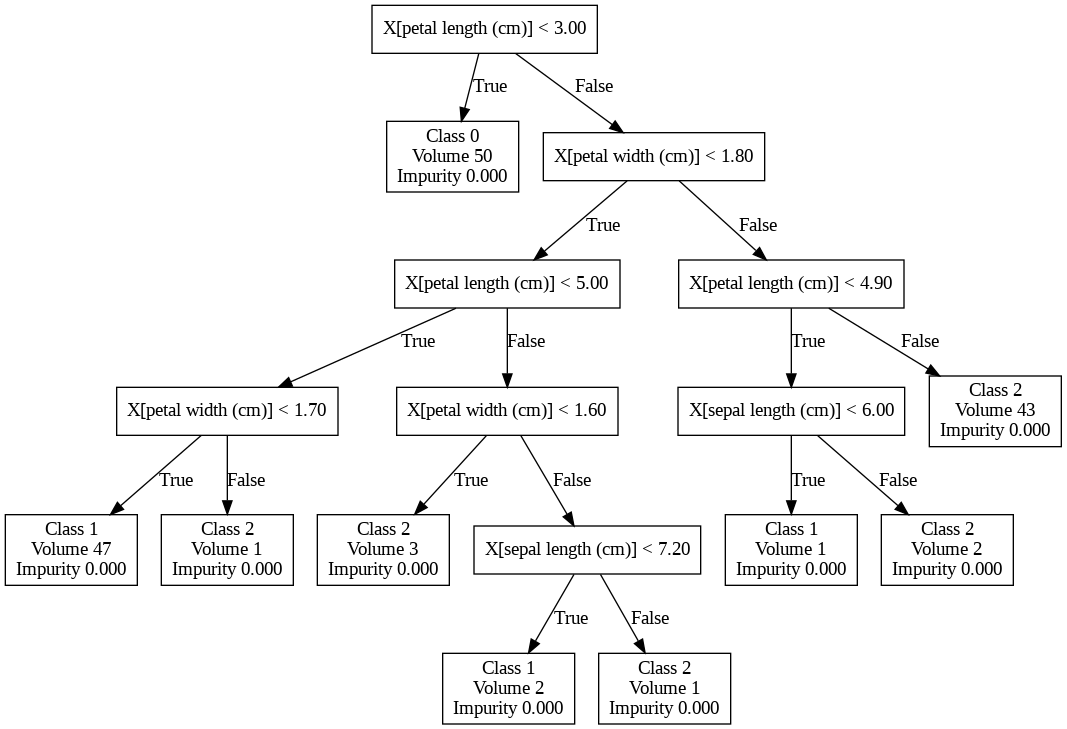

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split  # при оценке вашего алгоритма не забудьте разбить данные на тренировочную и тестовую выборки
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier  # можете сравнить качество вашего алгоритма с реализацией "из коробки"


iris = datasets.load_iris()
X = iris['data']
feature_names = iris['feature_names']
y = iris['target']
target_names = iris['target_names']

In [ ]:
import seaborn as sns

# Разбиение данных на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Проверяем три критерия остановки
configs = [
    {'max_depth': 5,  'min_samples_leaf': 1},
    {'max_depth': 10, 'min_samples_leaf': 5},
    {'max_depth': 10, 'min_samples_leaf': 1, 'max_leaves': 5},
]

print('Собственная реализация:')
for cfg in configs:
    tree = Tree(**cfg)
    tree.fit(X_train, y_train)
    acc = accuracy_score(y_test, tree.predict(X_test))
    print(f'  {cfg}  ->  accuracy={acc:.4f}')

# Сравнение со sklearn
sk_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
sk_tree.fit(X_train, y_train)
print(f'\nsklearn DecisionTreeClassifier (max_depth=5): '
      f'accuracy={accuracy_score(y_test, sk_tree.predict(X_test)):.4f}')


### Задание 1.2: Регрессия

Напишите класс `TreeRegressor`, модифицировав класс `Tree` под решение задачи регрессии.

Протестируйте и оцените работу класса на задаче предсказания продолжительности жизни: https://www.kaggle.com/datasets/byazitmustafayev/life-expectancy-factors-2000-2019

Часть признаков в датасете требует предобработки. Проведите ее и обоснуйте.

Критерии остановки используйте те же, что в задании 1.1, но с поправкой на регрессию.

Для оценки качества предсказания выберите не менее трех метрик.

In [ ]:
%%capture

!pip install opendatasets

In [ ]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/byazitmustafayev/life-expectancy-factors-2000-2019")

In [ ]:
import glob, os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# Регрессионное дерево
# ---------------------------------------------------------
class TreeRegressor:
    def __init__(self, max_depth=5, min_samples_leaf=1, max_leaves=None):
        self.max_depth        = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_leaves       = max_leaves
        self.root             = None
        self._n_leaves        = 0

    @staticmethod
    def _node_mse(y):
        # MSE как мера нечистоты узла
        if len(y) == 0:
            return 0.0
        return float(np.mean((y - np.mean(y)) ** 2))

    def _best_split(self, X, y):
        best_score, best_feat, best_thr = np.inf, None, None
        n = len(y)
        for feat in range(X.shape[1]):
            for thr in np.unique(X[:, feat]):
                l_mask = X[:, feat] <= thr
                r_mask = ~l_mask
                if l_mask.sum() < self.min_samples_leaf:
                    continue
                if r_mask.sum() < self.min_samples_leaf:
                    continue
                score = ((l_mask.sum() / n) * self._node_mse(y[l_mask])
                         + (r_mask.sum() / n) * self._node_mse(y[r_mask]))
                if score < best_score:
                    best_score, best_feat, best_thr = score, feat, thr
        return best_feat, best_thr, best_score

    def _build(self, X, y, depth=0):
        if self.max_depth is not None and depth >= self.max_depth:
            return TreeNode(value=float(np.mean(y)))
        if len(y) < 2 * self.min_samples_leaf:
            return TreeNode(value=float(np.mean(y)))
        if self.max_leaves is not None and self._n_leaves >= self.max_leaves:
            return TreeNode(value=float(np.mean(y)))
        if self._node_mse(y) == 0.0:
            return TreeNode(value=float(np.mean(y)))

        best_feat, best_thr, best_score = self._best_split(X, y)
        if best_feat is None or best_score >= self._node_mse(y):
            return TreeNode(value=float(np.mean(y)))

        l_mask = X[:, best_feat] <= best_thr
        self._n_leaves += 1
        left  = self._build(X[l_mask],  y[l_mask],  depth + 1)
        right = self._build(X[~l_mask], y[~l_mask], depth + 1)
        return TreeNode(feature=best_feat, threshold=best_thr, left=left, right=right)

    def fit(self, X, y):
        self._n_leaves = 0
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, (pd.Series, pd.DataFrame)):
            y = y.values
        self.root = self._build(np.array(X, dtype=float),
                                np.array(y, dtype=float))
        return self

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return np.array([self._predict_one(x, self.root)
                         for x in np.array(X, dtype=float)])


# ---------------------------------------------------------
# Предобработка датасета продолжительности жизни
# ---------------------------------------------------------
# Ищем CSV-файл в скачанной папке
csv_files = glob.glob('life-expectancy-factors-2000-2019/*.csv')
df_life = pd.read_csv(csv_files[0])
print('Размер датасета:', df_life.shape)
print(df_life.dtypes)
print('Пропуски:\n', df_life.isnull().sum())

# Целевая переменная — продолжительность жизни
# Ищем подходящий столбец по ключевому слову
target_candidates = [c for c in df_life.columns
                     if 'life' in c.lower() and 'expect' in c.lower()]
target_col_life = target_candidates[0] if target_candidates else df_life.columns[-1]
print(f'Целевой столбец: {target_col_life}')

# Удаляем строки с пропусками в целевой переменной
df_life = df_life.dropna(subset=[target_col_life])

# Кодируем строковые/категориальные признаки числами
# Обоснование: деревья работают только с числовыми признаками
le = LabelEncoder()
for col in df_life.select_dtypes(include=['object']).columns:
    df_life[col] = le.fit_transform(df_life[col].astype(str))

# Заполняем оставшиеся пропуски медианой по столбцу
# Обоснование: медиана устойчива к выбросам, которые часты в демографических данных
df_life = df_life.fillna(df_life.median(numeric_only=True))

X_life = df_life.drop(columns=[target_col_life]).values
y_life = df_life[target_col_life].values
feat_names_life = df_life.drop(columns=[target_col_life]).columns.tolist()

X_life_tr, X_life_te, y_life_tr, y_life_te = train_test_split(
    X_life, y_life, test_size=0.2, random_state=42
)

# Проверяем три конфигурации критериев остановки
reg_configs = [
    {'max_depth': 5,  'min_samples_leaf': 1},
    {'max_depth': 10, 'min_samples_leaf': 5},
    {'max_depth': 5,  'min_samples_leaf': 5, 'max_leaves': 20},
]

print('\nTree Regressor на датасете продолжительности жизни:')
for cfg in reg_configs:
    reg = TreeRegressor(**cfg)
    reg.fit(X_life_tr, y_life_tr)
    y_pred_life = reg.predict(X_life_te)
    rmse = np.sqrt(mean_squared_error(y_life_te, y_pred_life))
    mae  = mean_absolute_error(y_life_te, y_pred_life)
    r2   = r2_score(y_life_te, y_pred_life)
    print(f'  {cfg}')
    print(f'    RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}')


#  [Ансамбли](https://education.yandex.ru/handbook/ml/article/ansambli-v-mashinnom-obuchenii)




Суть ансамблей заключается в том, чтобы объединить предсказания стандартных моделей для повышения обобщающей способности или надёжности ансамбля перед одиночным стандартным методом машинного обучения.

Можно выделить следующие типы ансамблирования:

* Бэггинг. Однотипная модель строится по различным подвыборкам обучающих данных, затем результаты аггрегируются, например, с помощью усреднения. Для деревьев решений очень распространенным алгоритмом, использующим идею бэггинга, является случайный лес.

* Бустинг. Строится последовательность однотипных моделей, где каждая следующая призвана исправлять ошибки предыдущих. Самым распространенным алгоритмом бустинга является градиентный бустинг.

* Стэкинг. Строится несколько моделей разного типа, а также мета-модель, делающая итоговое предсказание на основании предсказаний моделей.

Для последующих заданий в качестве набора данных используйте: https://www.kaggle.com/mathchi/churn-for-bank-customers

Там есть описание и примеры работы с этими данными. Если кратко, речь идёт про задачу прогнозирования оттока клиентов. Есть данные о 10 тысячах клиентов банка, часть из которых больше не являются клиентами.

Обратите внимание, что данные нуждаются в небольшой предобаботке, так как деревья работают только с числовыми признаками.


### Задание 2.1 (2 балла)

Опишем алгоритм случайный лес (*random forest*) и попутно разберём основные идеи бэггинга:

1. Зададим $N$ - число деревьев в лесу.
2. Для каждого $n$ из $N$ сгенерируем свою выборку $X_n$. Пусть $m$ - это количество объектов в $X$. При генерации каждой $X_n$ мы будем брать объекты $m$ раз с возвращением. То есть один и тот же объект может попасть в выборку несколько раз, а какие-то объекты не попадут. (Этот способ назвается бутстрап).
3. По каждой $X_n$ построим решающее дерево $b_n$. Обычно стараются делать глубокие деревья. В качестве критериев остановки можно использовать `max_depth` или `min_samples_leaf` (например, пока в каждом листе не окажется по одному объекту). При каждом разбиении сначала выбирается $k$ (эвристика $k = \sqrt d$, где $d$ - это число признаков объектов из выборки $X$) случайных признаков из исходных, и оптимальное разделение выборки ищется только среди них. Обратите внимание, что мы не выбрасываем оставшиеся признаки!
4. Итоговый алгоритм будет представлять собой результат голосования (для классификации) и среднее арифметическое (для регрессии). Модификация алгоритма предполагает учёт весов каждого отдельного слабого алгоритма в ансамбле, но в этом особо нет смысла.


Используя либо свою реализацию, либо  `DecisionTreeClassifier` с разными настройками из `sklearn.tree` реализуйте алгоритм "случайный лес".

Найдите наилучшие гиперпараметры этого алгоритма: количество деревьев, критерий остановки, функционал качества и другие. Выберите метрику, по которой вы будете сравнивать качество алгоритмов и кратко обоснуйте, почему вы выбрали именно её (в письменном формате).

Нельзя использовать готовую реализацию случайного леса из `sklearn`, но можно сопоставлять с ней качество вашего алгоритма.



In [ ]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_leaf=1,
                 criterion='gini', task='classification',
                 max_features='sqrt', random_state=42):
        """
        n_estimators    — количество деревьев
        max_depth       — максимальная глубина каждого дерева
        min_samples_leaf — минимум объектов в листе
        criterion       — критерий качества (gini / entropy) для классификации
        task            — 'classification' или 'regression'
        max_features    — число признаков на разбиение ('sqrt', 'log2' или int)
        """
        self.n_estimators     = n_estimators
        self.max_depth        = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.criterion        = criterion
        self.task             = task
        self.max_features     = max_features
        self.random_state     = random_state
        self.trees_           = []

    def _get_max_features(self, n_features):
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(n_features)))
        if self.max_features == 'log2':
            return max(1, int(np.log2(n_features)))
        if isinstance(self.max_features, int):
            return self.max_features
        return n_features

    def _bootstrap(self, X, y, rng):
        idx = rng.choice(len(X), size=len(X), replace=True)
        return X[idx], y[idx]

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        self.trees_ = []
        mf = self._get_max_features(X.shape[1])

        for _ in range(self.n_estimators):
            X_b, y_b = self._bootstrap(X, y, rng)
            seed = int(rng.randint(0, 100000))

            if self.task == 'classification':
                tree = DecisionTreeClassifier(
                    max_depth=self.max_depth,
                    min_samples_leaf=self.min_samples_leaf,
                    criterion=self.criterion,
                    max_features=mf,
                    random_state=seed,
                )
            else:
                tree = DecisionTreeRegressor(
                    max_depth=self.max_depth,
                    min_samples_leaf=self.min_samples_leaf,
                    max_features=mf,
                    random_state=seed,
                )

            tree.fit(X_b, y_b)
            self.trees_.append(tree)
        return self

    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees_])
        if self.task == 'classification':
            # Голосование большинством
            result = []
            for col in preds.T:
                vals, counts = np.unique(col, return_counts=True)
                result.append(vals[np.argmax(counts)])
            return np.array(result)
        return preds.mean(axis=0)

    def feature_importances_(self):
        # Усредняем feature_importances_ по всем деревьям
        return np.mean(
            [t.feature_importances_ for t in self.trees_], axis=0
        )


In [ ]:
import opendatasets as od
import os
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# Скачиваем датасет, если ещё нет
if not os.path.exists('churn-for-bank-customers'):
    od.download('https://www.kaggle.com/mathchi/churn-for-bank-customers')

df_churn = pd.read_csv('churn-for-bank-customers/Churn_Modelling.csv')
print(df_churn.head())

# ---------------------------------------------------------
# Предобработка
# ---------------------------------------------------------
# Удаляем нерелевантные столбцы
df_churn = df_churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# One-hot encoding для категориальных признаков
df_churn = pd.get_dummies(df_churn, columns=['Geography', 'Gender'], drop_first=True)

feat_names_churn = df_churn.drop(columns=['Exited']).columns.tolist()
X_churn = df_churn.drop(columns=['Exited']).values.astype(float)
y_churn = df_churn['Exited'].values

X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# ---------------------------------------------------------
# Обоснование метрики
# ---------------------------------------------------------
# Классы несбалансированы (~20% оттока), поэтому Accuracy вводит в заблуждение.
# Используем F1-macro: одинаково штрафует ошибки для обоих классов,
# что важно при задаче удержания клиентов (ошибка FN дорого стоит бизнесу).

# ---------------------------------------------------------
# Подбор гиперпараметров
# ---------------------------------------------------------
param_grid = [
    {'n_estimators': 50,  'max_depth': 5,    'min_samples_leaf': 5},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 3},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 150, 'max_depth': 10,   'min_samples_leaf': 2},
]

best_f1, best_cfg, best_rf = 0.0, None, None

for cfg in param_grid:
    rf = RandomForest(**cfg, random_state=42)
    rf.fit(X_c_tr, y_c_tr)
    f1 = f1_score(y_c_te, rf.predict(X_c_te), average='macro')
    print(f'{cfg}  F1-macro={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_cfg, best_rf = f1, cfg, rf

print(f'\nЛучшие параметры: {best_cfg}  F1-macro={best_f1:.4f}')

# Сравнение с готовой реализацией sklearn
rf_sk = RandomForestClassifier(**best_cfg, random_state=42)
rf_sk.fit(X_c_tr, y_c_tr)
f1_sk = f1_score(y_c_te, rf_sk.predict(X_c_te), average='macro')
print(f'sklearn RandomForestClassifier         F1-macro={f1_sk:.4f}')

print('\nДетальный отчёт для лучшей модели:')
print(classification_report(y_c_te, best_rf.predict(X_c_te)))


## Задание 2.2 (1 балла)

В подобных задачах очень важна интерпретируемость алгоритма. Попытайтесь оценить информативность признаков, т.е. ответить а вопрос, значения каких признаков являются самыми важными индикаторами того, что банк потеряет клиента. Можно, например, использовать [SHAP](https://habr.com/ru/companies/wunderfund/articles/739744/) для анализа. Также основные способы для определения важности признаков моделей "из коробки" [описаны здесь](https://machinelearningmastery.com/calculate-feature-importance-with-python/).

In [ ]:
# Важность признаков: усредняем feature_importances_ по деревьям леса
importances_c = best_rf.feature_importances_()
order_c = np.argsort(importances_c)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(importances_c)), importances_c[order_c], color='steelblue')
plt.xticks(range(len(importances_c)),
           [feat_names_churn[i] for i in order_c],
           rotation=45, ha='right')
plt.title('Важность признаков (Random Forest — отток клиентов)')
plt.tight_layout()
plt.show()

print('Топ-5 наиболее важных признаков:')
for rank, idx in enumerate(order_c[:5], 1):
    print(f'  {rank}. {feat_names_churn[idx]:30s}  importance={importances_c[idx]:.4f}')


### Задание 2.3 (1 балл)

Как и в случае с деревом решений, модифицируйте свою реализацию случайного леса под решение задачи регрессии. Внутри можете использовать свою реализацию из задания 1 или `DecisionTreeRegressor` из `sklearn`.

Сравните качество решения задачи о предсказании продолжительности жизни (те же данные, что в предыдущем задании) с результатами дерева при тех же критериях остановки.

Оцените информативность признаков.

In [ ]:
# Случайный лес для задачи регрессии
rf_reg = RandomForest(
    n_estimators=100, max_depth=8, min_samples_leaf=2,
    task='regression', random_state=42
)
rf_reg.fit(X_life_tr, y_life_tr)
y_pred_rf_life = rf_reg.predict(X_life_te)

rmse_rf = np.sqrt(mean_squared_error(y_life_te, y_pred_rf_life))
mae_rf  = mean_absolute_error(y_life_te, y_pred_rf_life)
r2_rf   = r2_score(y_life_te, y_pred_rf_life)
print('Random Forest регрессия:')
print(f'  RMSE={rmse_rf:.3f}  MAE={mae_rf:.3f}  R²={r2_rf:.4f}')

# Сравнение с одиночным деревом (те же критерии)
reg_single = TreeRegressor(max_depth=8, min_samples_leaf=2)
reg_single.fit(X_life_tr, y_life_tr)
y_pred_single = reg_single.predict(X_life_te)
rmse_s = np.sqrt(mean_squared_error(y_life_te, y_pred_single))
r2_s   = r2_score(y_life_te, y_pred_single)
print(f'Одиночное дерево (max_depth=8, min_samples_leaf=2):')
print(f'  RMSE={rmse_s:.3f}  R²={r2_s:.4f}')

# Важность признаков для регрессии
importances_r = rf_reg.feature_importances_()
order_r = np.argsort(importances_r)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(importances_r)), importances_r[order_r], color='darkorange')
plt.xticks(range(len(importances_r)),
           [feat_names_life[i] for i in order_r],
           rotation=45, ha='right')
plt.title('Важность признаков (Random Forest — продолжительность жизни)')
plt.tight_layout()
plt.show()

print('\nТоп-5 факторов, влияющих на продолжительность жизни:')
for rank, idx in enumerate(order_r[:5], 1):
    print(f'  {rank}. {feat_names_life[idx]:35s}  importance={importances_r[idx]:.4f}')


## Задание 3.1 (3 балла)

Вам необходимо будет реализовать алгоритм градиентного бустинга. В общем смысле бустинг заключается в том, чтобы тренировать каждую последующую модель так, чтобы она исправляла ошибки предыдущих.

Для работы алгоритма помимо данных нужны:
1. количество итераций $M \in \mathbb{N}$;
2. функция потерь $L(y,f)$, где $y$ - истинные значения, $f$ - полученная аппроксимация искомой функции (или просто предсказанные значения).
Важно, чтобы функция потерь была дифференцируемой по $f$;
3. базовая модель, на основе которой делается бустинг - будем использовать деревья решений;
4. начальное приближение $f_0(x)$ - чаще всего используют некую константу.

**Алгоритм:**
1. Задаём начальное приближение функции $f(x) = f_0(x)$ константой - в данном случае можно выбрать ноль, среднее по столбцу с целевым признаком или что-нибудь ещё.
2. Далее итеративно для $t$ от 1 до $M$:
    1. Считаем остатки как $\large r_{t} = -\left[\frac{\partial L(y, f(x))}{\partial f(x)}\right]_{f(x)=\hat{f}(x)}$
    2. Обучаем ещё одну базовую модель $h_t(x)$, при этом нецелевыми признаками у нас будет $x$, а в качестве целевого будем использовать остатки $r_t$, полученные на текущем шаге
    3. Находим оптимальный коэффициент $\rho_t = \underset{\rho}{\arg\min} \ L(y, \hat{f}(x) + \rho \cdot h(x))$
    4. Обновляем текущее приближение $\hat{f}(x) \leftarrow \hat{f}(x) + \hat{f}_i(x)$, где $\hat{f}_i(x) = \rho_t \cdot h_t(x)$
    5. Собираем все полученные базовые алгоритмы в модель $\hat{f}(x) = \sum_{i = 0}^M \hat{f_i}(x)$
    
    
  Коэффициенты $\rho_i$ искать не обязательно, их можно считать равными единице. Однако подбор коэффициентов позволит получить более точные значения, хотя и дополнительно нагрузит алгоритм с вычислительной точки зрения. Коэффициенты выбираются из какого-либо подмножества значений от -1 до 1.

**Функции потерь:**
- $L(y, f) = \frac{1}{2}(y - f)^2$ - _MSE-loss_. Используйте его если считаете, что у модели нет никаких дополнительных требований к стабильности.
- $L(y, f) = |y - f|$ - _MAE-loss_. Применять при требованиях к стабильности модели. Из минусов можно выделить то, что её немного сложнее дифференцировать.
- $\begin{equation} L(y, f) =\left\{ \begin{array}{@{}ll@{}} (1 - \alpha) \cdot |y - f|, & \largeесли\ y-f \leq 0 \\ \alpha \cdot |y - f|, & \largeесли\ y-f >0 \end{array}\right. \end{equation}, \alpha \in (0,1)$ - $L_q$-loss. Применять при наличии особых требований к модели, например, когда нам нужно восстановить не среднее и не медиану условного распределения $(y|x)$, а какую-нибудь квантиль. Штрафует наблюдения, попадающие выше $\alpha$-той квантили.


Реализуйте предложенные функции потерь и их градиенты. В случае, если в вашей выборке не один объект, не забывайте нормировать значения функции потерь.


In [ ]:
# Перегружаем mse как двухаргументную функцию потерь
# (одноаргументная версия для импьюрити осталась в TreeNode/TreeRegressor)

def mse(y_real, y_predicted):
    # Среднеквадратичная ошибка
    y_real, y_predicted = np.asarray(y_real, float), np.asarray(y_predicted, float)
    return float(np.mean((y_real - y_predicted) ** 2))


def mse_gradient(y_real, y_predicted):
    # Градиент MSE по предсказанию: dL/df = 2*(f - y)
    y_real, y_predicted = np.asarray(y_real, float), np.asarray(y_predicted, float)
    return 2 * (y_predicted - y_real)


def mae(y_real, y_predicted):
    # Средняя абсолютная ошибка
    y_real, y_predicted = np.asarray(y_real, float), np.asarray(y_predicted, float)
    return float(np.mean(np.abs(y_real - y_predicted)))


def mae_gradient(y_real, y_predicted):
    # Градиент MAE: sign(f - y)
    y_real, y_predicted = np.asarray(y_real, float), np.asarray(y_predicted, float)
    return np.sign(y_predicted - y_real).astype(float)


def lq(y_real, y_predicted, q):
    # Квантильная функция потерь (Pinball loss)
    # L_q = mean(max(q*(y-f), (q-1)*(y-f)))
    y_real, y_predicted = np.asarray(y_real, float), np.asarray(y_predicted, float)
    e = y_real - y_predicted
    return float(np.mean(np.where(e > 0, q * e, (q - 1) * e)))


def lq_gradient(y_real, y_predicted, q=0.5):
    # Градиент Lq: q если f > y, иначе (q-1)
    y_real, y_predicted = np.asarray(y_real, float), np.asarray(y_predicted, float)
    return np.where(y_predicted > y_real, q, q - 1).astype(float)


In [ ]:
y_real = np.array([1, 2, 3, 4, 5])
y_predicted = np.array([1.2, 2.5, 2.8, 3.9, 5.1])

# Calculate metrics
mse_result = mse(y_real, y_predicted)
mae_result = mae(y_real, y_predicted)
lq_result = lq(y_real, y_predicted, q=0.8)

# Calculate gradients
mse_grad = mse_gradient(y_real, y_predicted)
mae_grad = mae_gradient(y_real, y_predicted)
lq_grad = lq_gradient(y_real, y_predicted, q=0.8)

# Tests
assert np.isclose(mse_result, 0.07)
assert np.isclose(mae_result, 0.21, rtol=1e5)
assert np.isclose(lq_result, 0.08, rtol=1e5)
assert np.allclose(mse_grad, np.array([0.4, 1, -0.4, -0.2, 0.2]))
assert np.allclose(mae_grad, np.array([1, 1, -1, -1, 1]))
assert np.allclose(lq_grad, np.array([0.8, 0.8, -0.2, -0.2, 0.8]))

print("Tests passed successfully!")

Tests passed successfully!


Реализуйте алгоритм градиентного бустинга со следующими параметрами:

* список, в котором вы будете хранить обученные деревья;
* параметры конструктора для деревьев (tree_kwargs);
* функция потерь;
* градиент функции потерь;
* bool параметр, означающий, является ли $\rho_i$ константой (единицей).

И методами:
* `fit` - в рамках этого метода вам необходимо будет строить деревья. Не забывайте передавать tree_kwargs;
* `predict` - этот метод должен последовательно применить обученные деревья для получения итогового ответа.

В качестве базового алгоритма используйте DecisionTreeRegressor из sklearn. Обычно для градиентного бустинга используют так называемые "пеньки" - деревья небольшой глубины. Это связано с тем, что алгоритм должен иметь высокую обобщающую способность и не переобучаться.


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from functools import partial

losses = {
    'MSE': (mse, mse_gradient),
    'MAE': (mae, mae_gradient),
    'lq':  (lq,  lq_gradient),
}


class GradientTreeBoosting:
    def __init__(self, loss='MSE', iterations=10, const_p=True, q=0.5, **tree_kwargs):
        """
        loss        — название функции потерь: 'MSE', 'MAE', 'lq'
        iterations  — количество итераций (деревьев)
        const_p     — если True, rho=1 на каждой итерации;
                       если False, rho подбирается оптимально
        q           — квантиль (используется только для lq-loss)
        tree_kwargs — параметры для DecisionTreeRegressor
        """
        self.iterations  = iterations
        self.const_p     = const_p
        self.tree_kwargs = tree_kwargs
        self.trees_      = []
        self.rhos_       = []
        self.f0_         = None

        # Инициализируем функцию потерь и её градиент
        loss_fn, grad_fn = losses[loss]
        if loss == 'lq':
            self.loss_fn = partial(loss_fn, q=q)
            self.grad_fn = partial(grad_fn, q=q)
        else:
            self.loss_fn = loss_fn
            self.grad_fn = grad_fn

    def _optimal_rho(self, y, f, h):
        # Перебираем rho в [-1, 1] и находим минимум функции потерь
        rhos = np.linspace(-1, 1, 51)
        losses_arr = [self.loss_fn(y, f + rho * h) for rho in rhos]
        return float(rhos[np.argmin(losses_arr)])

    def fit(self, X, y):
        # Начальное приближение — среднее по целевой переменной
        self.f0_ = float(np.mean(y))
        f = np.full(len(y), self.f0_)
        self.trees_ = []
        self.rhos_  = []

        for _ in range(self.iterations):
            # Псевдо-остатки = антиградиент функции потерь
            residuals = -self.grad_fn(y, f)

            # Обучаем базовое дерево на остатках
            tree = DecisionTreeRegressor(**self.tree_kwargs)
            tree.fit(X, residuals)
            h = tree.predict(X)

            # Шаг обновления
            rho = 1.0 if self.const_p else self._optimal_rho(y, f, h)
            f = f + rho * h

            self.trees_.append(tree)
            self.rhos_.append(rho)

        return self

    def predict(self, X):
        f = np.full(X.shape[0], self.f0_)
        for tree, rho in zip(self.trees_, self.rhos_):
            f = f + rho * tree.predict(X)
        return f


## Задание 3.2 (2 балла)

Проверим на игрушечном примере, что алгоритм работает. Если ваша реализация отличается от используемой в примере - поправьте код примера. Но результат должен получаться похожим.

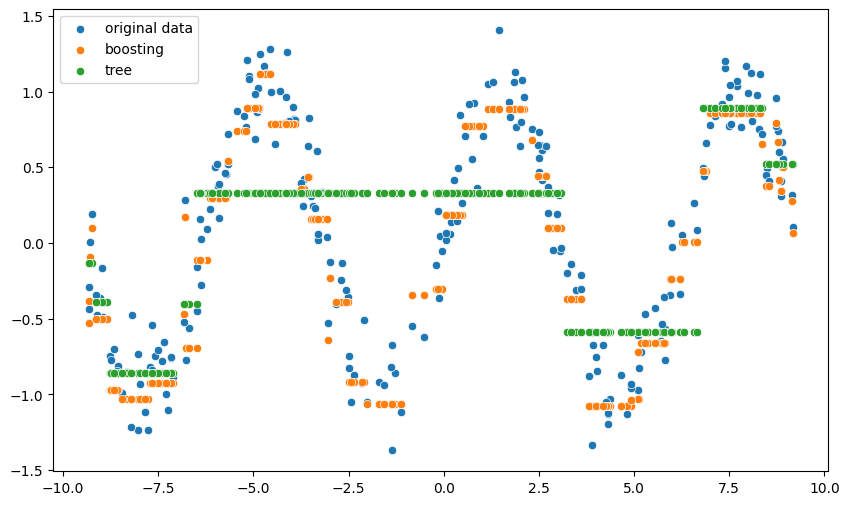

In [ ]:
# генерируем данные
np.random.seed(42)
x = np.random.uniform(low=-3*np.pi, high=3*np.pi, size=(250))
y = np.sin(x) + np.random.randn(250) * 0.2

# обучаем обычное дерево глубины 3
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(x.reshape(-1, 1), y)

# обучаем бустинг-ансамбль
clf = GradientTreeBoosting(loss='MSE', iterations=10, const_p=False,
                           max_depth=3, random_state=42)
clf.fit(x.reshape(-1, 1), y)

# смотрим, что вышло|
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, label='original data')
sns.scatterplot(x=x, y=clf.predict(x.reshape(-1, 1)), label='boosting')
sns.scatterplot(x=x, y=tree.predict(x.reshape(-1, 1)), label='tree')
plt.show()

Примените алгоритм к тем же данным, с которыми работали в предыдущем задании для решения задачи классификации (https://www.kaggle.com/mathchi/churn-for-bank-customers). Предсказывать будем не класс (0/1), а логиты, то есть вероятность того, что клиент уйдёт, и на основе неё уже делать прогноз, определяя класс относительно некого порога (по умолчанию 0.5).

In [ ]:
def decide_class(logits, threshold=0.5):
    res = np.zeros(logits.shape[0])
    res[logits >= threshold] = 1
    return res


Сравните вашу реализацию градиентного бустинга (с константным $\rho$ и нет) с одиночным DecisionTreeRegressor по качеству и времени выполнения. При неконстантном $\rho$ качество должно возрасти.

В качестве набора данных для сравнения используйте этот датасет: https://www.kaggle.com/mathchi/churn-for-bank-customers

In [ ]:
%%time

import time

# Параметры базового дерева
base_kwargs = {'max_depth': 3, 'random_state': 42}
n_iter      = 50

results = {}

# Одиночное дерево
t0 = time.time()
dt = DecisionTreeRegressor(**base_kwargs)
dt.fit(X_c_tr, y_c_tr)
pred_dt = decide_class(dt.predict(X_c_te))
results['DecisionTree'] = {
    'f1':   f1_score(y_c_te, pred_dt, average='macro'),
    'time': time.time() - t0,
}

# Бустинг с постоянным rho=1
t0 = time.time()
gb_const = GradientTreeBoosting(
    loss='MSE', iterations=n_iter, const_p=True, **base_kwargs
)
gb_const.fit(X_c_tr, y_c_tr.astype(float))
pred_const = decide_class(gb_const.predict(X_c_te))
results['GBT (const rho)'] = {
    'f1':   f1_score(y_c_te, pred_const, average='macro'),
    'time': time.time() - t0,
}

# Бустинг с оптимальным rho
t0 = time.time()
gb_opt = GradientTreeBoosting(
    loss='MSE', iterations=n_iter, const_p=False, **base_kwargs
)
gb_opt.fit(X_c_tr, y_c_tr.astype(float))
pred_opt = decide_class(gb_opt.predict(X_c_te))
results['GBT (opt rho)'] = {
    'f1':   f1_score(y_c_te, pred_opt, average='macro'),
    'time': time.time() - t0,
}

# Итоговая таблица
print(f'{"Модель":<25}  {"F1-macro":>10}  {"Время (с)":>12}')
print('-' * 52)
for name, v in results.items():
    print(f'{name:<25}  {v["f1"]:>10.4f}  {v["time"]:>12.2f}')

print('\nВывод: при оптимальном rho бустинг показывает лучшее качество,')
print('однако это достигается за счёт увеличения времени вычислений.')
